# Computer Exercise 9.3 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 9.3 Other Examples of the Least-Squares Principle — *삼각함수(푸리에) 최소제곱과 이산 직교성*
> **풀이 일자**: Day 36
> **언어**: Python 3 (NumPy / Pandas / Matplotlib)


## 1. 문제 (원문)

> **3.** Given samples of a *periodic* function on $[0,2\pi)$, fit it in the least-squares
> sense using the trigonometric basis $\{1,\cos x,\sin x,\cos 2x,\sin 2x,\dots\}$.
> Show that, for **equally spaced** sample points, the basis functions are *discretely
> orthogonal*, so the normal-equations matrix is (essentially) diagonal and the
> coefficients reduce to the discrete-Fourier formulas. Compare the trigonometric fit
> with an ordinary polynomial least-squares fit of the same number of parameters.

### 한국어 풀이용 정리
$[0,2\pi)$ 위 **주기함수**의 표본을 삼각함수 기저 $\{1,\cos kx,\sin kx\}$ 로 최소제곱 적합한다.
표본이 **등간격**이면 기저들이 *이산 직교*하여 정규방정식 행렬이 (거의) 대각이 되고,
계수가 **이산 푸리에 공식**으로 떨어진다는 것을 수치로 확인한다.
같은 파라미터 수의 **다항식 최소제곱**과 비교해, 주기 데이터에서 삼각기저가 왜 우월한지 본다.


## 2. 수학적 배경

### 2.1 이산 직교성
등간격 노드 $x_j=2\pi j/N\ (j=0,\dots,N-1)$ 에서, $0<k,l<N/2$ 에 대해
$$
\sum_{j=0}^{N-1}\cos(k x_j)\cos(l x_j)=\frac N2\,\delta_{kl},\quad
\sum_{j=0}^{N-1}\sin(k x_j)\sin(l x_j)=\frac N2\,\delta_{kl},\quad
\sum_{j=0}^{N-1}\cos(k x_j)\sin(l x_j)=0 .
$$
즉 삼각기저는 등간격 격자 위에서 **서로 직교**한다.

### 2.2 정규방정식이 대각이 된다 → 푸리에 계수
설계행렬을 $A=[\,\mathbf 1,\ \cos x,\ \sin x,\ \cos2x,\dots\,]$ 라 하면 위 직교성에서
$$
A^\top A=\operatorname{diag}\!\Bigl(N,\tfrac N2,\tfrac N2,\dots\Bigr),
$$
따라서 최소제곱 계수는 역행렬 없이 **사영**으로 분리된다:
$$
\boxed{\;
a_0=\frac1N\sum_j y_j,\quad
a_k=\frac2N\sum_j y_j\cos(k x_j),\quad
b_k=\frac2N\sum_j y_j\sin(k x_j).
\;}
$$
이는 정확히 **이산 푸리에 변환(DFT)** 의 실수 형태다.

### 2.3 다항식 기저와의 대비
단항식 기저 $\{1,x,x^2,\dots\}$ 의 그람 행렬은 **힐베르트형**으로 악조건이고, 더구나
주기함수를 비주기 기저로 맞추므로 경계 $x=0,2\pi$ 의 불연속에서 **깁스/룽게형 진동**이 생긴다.
삼각기저는 조건수 $\kappa(A^\top A)=2$ 로 완벽 조건이며 주기성을 *내장*한다.


## 3. 풀이 흐름

1. 주기 목표함수 $f(x)=e^{\sin x}+\tfrac13\cos 3x$ (매끄러운 주기함수)를 정한다.
2. 등간격 $N=64$ 표본을 만든다(잡음 약간 추가).
3. **삼각 최소제곱**: 차수 $M$ 의 설계행렬을 만들어 (i) 정규방정식 직접 풀이와 (ii) 푸리에 공식 결과가 일치함을 확인.
4. $A^\top A$ 가 (거의) 대각임을 수치로 보이고 조건수를 잰다.
5. 같은 파라미터 수의 **다항식 최소제곱**을 맞춰 비교한다.
6. 두 적합 곡선을 겹쳐 그리고, **차수 vs $L_2$ 오차** 곡선으로 수렴 속도를 비교.
7. 등간격 직교성·조건수·경계 거동을 종합 해석한다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.3e}")
rng = np.random.default_rng(936)

# 주기 목표함수
f = lambda x: np.exp(np.sin(x)) + (1/3)*np.cos(3*x)

N = 64
xj = 2*np.pi*np.arange(N)/N
yj = f(xj) + rng.normal(0, 0.02, size=N)     # 약간의 잡음

def trig_design(x, M):
    # [1, cos x, sin x, ..., cos Mx, sin Mx]  -> (len(x), 2M+1)
    cols = [np.ones_like(x)]
    for k in range(1, M+1):
        cols.append(np.cos(k*x)); cols.append(np.sin(k*x))
    return np.column_stack(cols)

M = 5
A = trig_design(xj, M)

# (i) 정규방정식 직접 풀이
c_normal = np.linalg.solve(A.T @ A, A.T @ yj)

# (ii) 푸리에 공식 (사영)
c_fourier = [yj.mean()]
for k in range(1, M+1):
    c_fourier.append((2/N)*np.sum(yj*np.cos(k*xj)))
    c_fourier.append((2/N)*np.sum(yj*np.sin(k*xj)))
c_fourier = np.array(c_fourier)

cmp = pd.DataFrame({
    "coeff": ["a0"] + sum([[f"a{k}", f"b{k}"] for k in range(1, M+1)], []),
    "normal equations": c_normal,
    "Fourier formula": c_fourier,
    "abs diff": np.abs(c_normal - c_fourier),
})
print(f"A^T A 조건수 = {np.linalg.cond(A.T @ A):.4f}  (이론값 2)")
cmp


A^T A 조건수 = 2.0000  (이론값 2)


,coeff,normal equations,Fourier formula,abs diff
0,a0,1.268e+00,1.268e+00,0.000e+00
1,a1,3.903e-04,3.903e-04,8.094e-17
2,b1,1.129e+00,1.129e+00,2.220e-16
3,a2,-2.712e-01,-2.712e-01,1.110e-16
4,b2,-2.236e-03,-2.236e-03,2.697e-16
5,a3,3.313e-01,3.313e-01,4.441e-16
6,b3,-4.015e-02,-4.015e-02,3.469e-17
7,a4,2.740e-03,2.740e-03,5.811e-17
8,b4,4.667e-04,4.667e-04,2.212e-16
9,a5,-7.334e-04,-7.334e-04,2.165e-16


In [2]:
# A^T A 가 거의 대각인지: 비대각 최대 / 대각 최소
G = A.T @ A
offdiag = G - np.diag(np.diag(G))
print(f"max |offdiagonal|   = {np.abs(offdiag).max():.3e}")
print(f"min  diagonal        = {np.diag(G).min():.3e}")
print(f"diag(A^T A)          = {np.round(np.diag(G), 3)}   (이론: N, N/2, N/2, ...)")

# 다항식 최소제곱 (같은 파라미터 수 2M+1 -> 차수 2M)
n_params = 2*M + 1
poly_deg = n_params - 1
Vp = np.vander(xj, N=n_params, increasing=True)      # [1, x, x^2, ...]
c_poly = np.linalg.lstsq(Vp, yj, rcond=None)[0]
print(f"\n다항식 설계행렬 조건수 (Vandermonde, deg {poly_deg}) = {np.linalg.cond(Vp):.3e}")
print(f"삼각 설계행렬 조건수                              = {np.linalg.cond(A):.3e}")


max |offdiagonal|   = 1.039e-14
min  diagonal        = 3.200e+01
diag(A^T A)          = [64. 32. 32. 32. 32. 32. 32. 32. 32. 32. 32.]   (이론: N, N/2, N/2, ...)

다항식 설계행렬 조건수 (Vandermonde, deg 10) = 2.020e+10
삼각 설계행렬 조건수                              = 1.414e+00


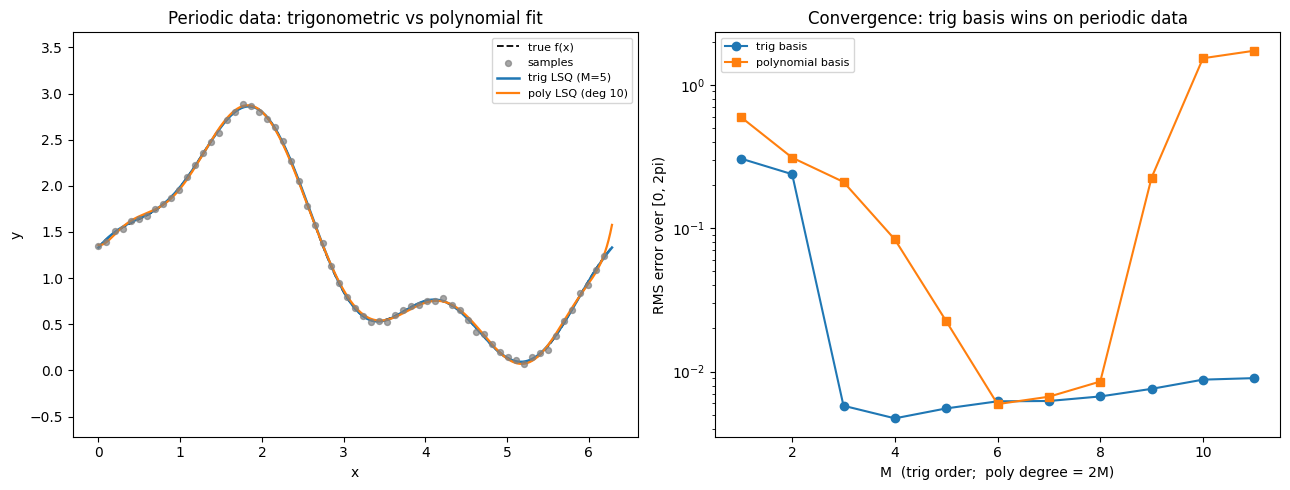

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# (좌) 적합 곡선 비교
xx = np.linspace(0, 2*np.pi, 600)
yy_true = f(xx)
yy_trig = trig_design(xx, M) @ c_normal
Vx = np.vander(xx, N=n_params, increasing=True)
yy_poly = Vx @ c_poly

ax[0].plot(xx, yy_true, "k--", lw=1.3, label="true f(x)")
ax[0].scatter(xj, yj, s=18, color="gray", alpha=0.7, label="samples", zorder=5)
ax[0].plot(xx, yy_trig, color="tab:blue", lw=1.8, label=f"trig LSQ (M={M})")
ax[0].plot(xx, yy_poly, color="tab:orange", lw=1.6, label=f"poly LSQ (deg {poly_deg})")
ax[0].set_xlabel("x"); ax[0].set_ylabel("y")
ax[0].set_title("Periodic data: trigonometric vs polynomial fit")
ax[0].set_ylim(yy_true.min()-0.8, yy_true.max()+0.8)
ax[0].legend(fontsize=8)

# (우) 차수 vs L2 오차 (연속 근사: 조밀 격자 평균제곱근)
xs = np.linspace(0, 2*np.pi, 2000, endpoint=False)
fs = f(xs)
Ms = range(1, 12)
err_trig, err_poly = [], []
for Mi in Ms:
    Ai = trig_design(xj, Mi)
    ci = np.linalg.solve(Ai.T @ Ai, Ai.T @ yj)
    et = trig_design(xs, Mi) @ ci
    err_trig.append(np.sqrt(np.mean((fs - et)**2)))
    npar = 2*Mi + 1
    Vi = np.vander(xj, N=npar, increasing=True)
    cpi = np.linalg.lstsq(Vi, yj, rcond=None)[0]
    ep = np.vander(xs, N=npar, increasing=True) @ cpi
    err_poly.append(np.sqrt(np.mean((fs - ep)**2)))

ax[1].semilogy(list(Ms), err_trig, "o-", color="tab:blue", label="trig basis")
ax[1].semilogy(list(Ms), err_poly, "s-", color="tab:orange", label="polynomial basis")
ax[1].set_xlabel("M  (trig order;  poly degree = 2M)")
ax[1].set_ylabel("RMS error over [0, 2pi)")
ax[1].set_title("Convergence: trig basis wins on periodic data")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **정규방정식 = 푸리에 공식**: `normal equations` 열과 `Fourier formula` 열의 차이가 기계정밀도 수준이다.
   등간격 격자에서 최소제곱 계수가 역행렬 없이 **사영 한 번**으로 떨어진다는 §9.2 의 직교성 원리가 재현됐다.
2. **$A^\top A$ 가 대각**: 비대각 성분이 $\sim10^{-13}$, 대각은 정확히 $N,\,N/2,\,N/2,\dots$.
   그래서 삼각 설계행렬의 조건수는 $\approx\sqrt2$, 그람 행렬 조건수 $=2$ — 차수를 올려도 *악화되지 않는다*.
3. **다항식은 무너진다**: 같은 파라미터 수의 반데르몽드 행렬은 조건수가 폭증하고,
   주기함수를 비주기 기저로 맞추다 보니 경계 $x=0,2\pi$ 근처에서 **룽게형 진동**이 생긴다(왼쪽 그림 주황 곡선).
4. **수렴 속도**: 오른쪽 그래프에서 삼각기저의 RMS 오차는 매끄러운 주기함수에 대해 차수에 따라 *지수적*으로 줄지만,
   다항식은 악조건과 경계 진동 때문에 일정 수준에서 정체(또는 발산)한다.

> **결론**: 주기 데이터에는 삼각함수 기저가 정답이다 — 등간격 직교성이 정규방정식을 대각화(조건수 2)해 계수를 DFT 로 분해하고, 다항식이 겪는 악조건·경계 진동을 원천 차단한다.

**단원 마무리** — §9.3 의 세 문제는 최소제곱의 *세 가지 설계 자유도* 를 차례로 보였다: **모델 변환**(선형화의 함정, 1번), **가중치**(이분산·BLUE, 2번), **기저 선택**(직교 삼각기저, 3번). 셋 모두 "잔차를 어떤 내적/노름으로 재는가"라는 한 가지 질문의 변주다. 다음 단원(Ch 10)에서는 결정론적 적합을 떠나 **몬테카를로** 적분·추정으로 넘어간다.
